<a href="https://colab.research.google.com/github/OlaniyiSegunIsrael/Assignment-12-SO/blob/main/Assignment%2012.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Assignment 12: Neural Network and Deep Learning Basics.

##Assignment link
- Google Colab: https://colab.research.google.com/drive/1aqdN37H8NDco3ZIqxrIMlW3Z65hmZCOb?usp=sharing
- Git Hub: https://github.com/OlaniyiSegunIsrael/Assignment-12-SO

In [21]:
!apt-get install -y git
!git config --global user.email "segun.olaniyi@students.williscollege.com"
!git config --global user.name "OlaniyiSegunIsrael"

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
git is already the newest version (1:2.34.1-1ubuntu1.17).
0 upgraded, 0 newly installed, 0 to remove and 2 not upgraded.


In [22]:
!git clone https://github.com/OlaniyiSegunIsrael/Assignment-12-SO.git
%cd Assignment-12-SO
!ls

Cloning into 'Assignment-12-SO'...
remote: Enumerating objects: 3, done.
remote: Counting objects: 100% (3/3), done.
remote: Compressing objects: 100% (2/2), done.
remote: Total 3 (delta 0), reused 0 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (3/3), done.
/content/Assignment-12-SO
README.md


In [23]:
!git status

On branch main
Your branch is up to date with 'origin/main'.

nothing to commit, working tree clean


In [1]:
# 1. Import Libraries

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from tensorflow.keras.datasets import fashion_mnist
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.preprocessing.image import ImageDataGenerator

from sklearn.metrics import classification_report, confusion_matrix

In [2]:
# 2. Load Dataset

(X_train, y_train), (X_test, y_test) = fashion_mnist.load_data()

class_names = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
               'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']

print("Training shape:", X_train.shape)
print("Test shape:", X_test.shape)

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Training shape: (60000, 28, 28)
Test shape: (10000, 28, 28)


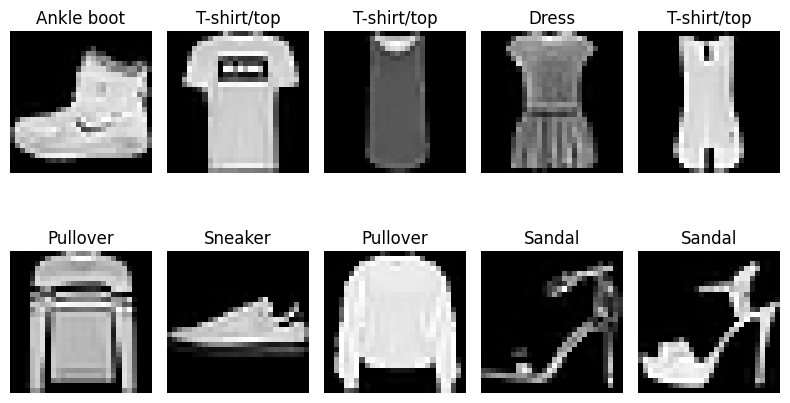

In [4]:
# 3. Visualize Sample Images

plt.figure(figsize=(8, 5))
for i in range(10):
    plt.subplot(2, 5, i+1)
    plt.imshow(X_train[i], cmap='gray')
    plt.title(class_names[y_train[i]])
    plt.axis('off')
plt.tight_layout()
plt.show()

In [5]:
# 4. Preprocessing

# Normalize (0-255 → 0-1)
X_train = X_train / 255.0
X_test = X_test / 255.0

# One-hot encode labels
y_train_cat = to_categorical(y_train, 10)
y_test_cat = to_categorical(y_test, 10)

In [6]:
# 5. Data Augmentation (Optional)

datagen = ImageDataGenerator(
    rotation_range=10,
    zoom_range=0.1,
    width_shift_range=0.1,
    height_shift_range=0.1)

# reshape for augmentation (needs channel dimension)
X_train_aug = X_train.reshape(-1, 28, 28, 1)

In [8]:
# 6. Build Neural Network Model

model = Sequential([
    Flatten(input_shape=(28, 28)),
    Dense(128, activation='relu'),
    Dense(64, activation='relu'),
    Dense(10, activation='softmax')])

In [9]:
# 7. Compile Model

model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy'])

model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_1 (Flatten)             │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 109,386 (427.29 KB)

 Trainable params: 109,386 (427.29 KB)

 Non-trainable params: 0 (0.00 B)

In [10]:
# 8. Train Model

history = model.fit(
    datagen.flow(X_train_aug, y_train_cat, batch_size=64),
    epochs=10,
    validation_data=(X_test, y_test_cat))

Epoch 1/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 28s 28ms/step - accuracy: 0.7032 - loss: 0.7916 - val_accuracy: 0.7723 - val_loss: 0.5966
Epoch 2/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 26s 28ms/step - accuracy: 0.7631 - loss: 0.6271 - val_accuracy: 0.8123 - val_loss: 0.5225
Epoch 3/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 26s 28ms/step - accuracy: 0.7784 - loss: 0.5827 - val_accuracy: 0.8186 - val_loss: 0.4978
Epoch 4/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 26s 28ms/step - accuracy: 0.7880 - loss: 0.5566 - val_accuracy: 0.8180 - val_loss: 0.4841
Epoch 5/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 26s 28ms/step - accuracy: 0.7980 - loss: 0.5361 - val_accuracy: 0.8208 - val_loss: 0.4791
Epoch 6/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 26s 28ms/step - accuracy: 0.8017 - loss: 0.5258 - val_accuracy: 0.8291 - val_loss: 0.4614
Epoch 7/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 26s 28ms/step - accuracy: 0.8052 - loss: 0.5111 - val_accuracy: 0.8215 - val_loss: 0.4641
Epoch 8/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 26s 28ms/step - accuracy: 0.8090 - loss: 0.5027 - 

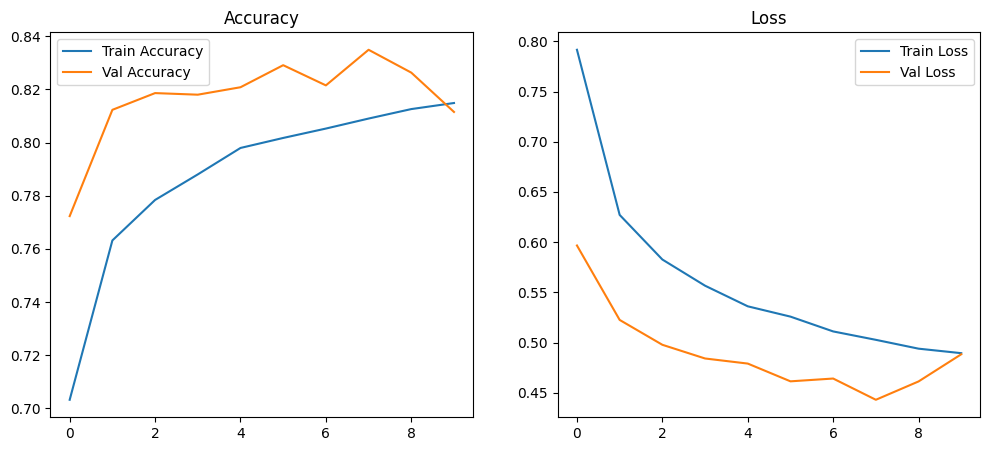

In [11]:
# 9. Plot Training History

plt.figure(figsize=(12,5))

# Accuracy plot
plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.legend()
plt.title("Accuracy")

# Loss plot
plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.legend()
plt.title("Loss")

plt.show()

In [12]:
# 10. Model Evaluation

test_loss, test_acc = model.evaluate(X_test, y_test_cat)
print("Test Accuracy:", test_acc)

# Predictions
y_pred = model.predict(X_test)
y_pred_classes = np.argmax(y_pred, axis=1)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8115 - loss: 0.4883
Test Accuracy: 0.8115000128746033
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


In [13]:
# 11. Classification Report

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred_classes, target_names=class_names))


Classification Report:

              precision    recall  f1-score   support

 T-shirt/top       0.86      0.68      0.76      1000
     Trouser       0.99      0.96      0.97      1000
    Pullover       0.61      0.75      0.68      1000
       Dress       0.80      0.89      0.84      1000
        Coat       0.79      0.43      0.56      1000
      Sandal       0.97      0.93      0.95      1000
       Shirt       0.50      0.71      0.59      1000
     Sneaker       0.92      0.87      0.90      1000
         Bag       0.98      0.93      0.96      1000
  Ankle boot       0.88      0.97      0.92      1000

    accuracy                           0.81     10000
   macro avg       0.83      0.81      0.81     10000
weighted avg       0.83      0.81      0.81     10000



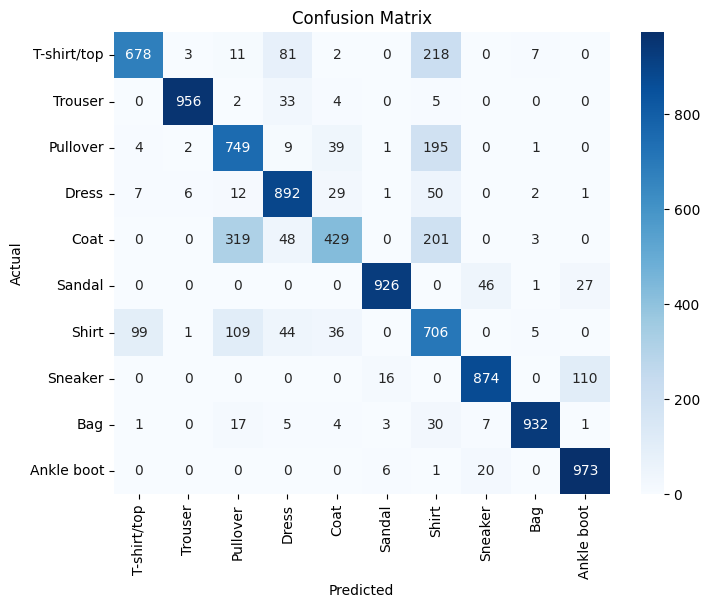

In [14]:
# 12. Confusion Matrix

cm = confusion_matrix(y_test, y_pred_classes)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names,
            yticklabels=class_names)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

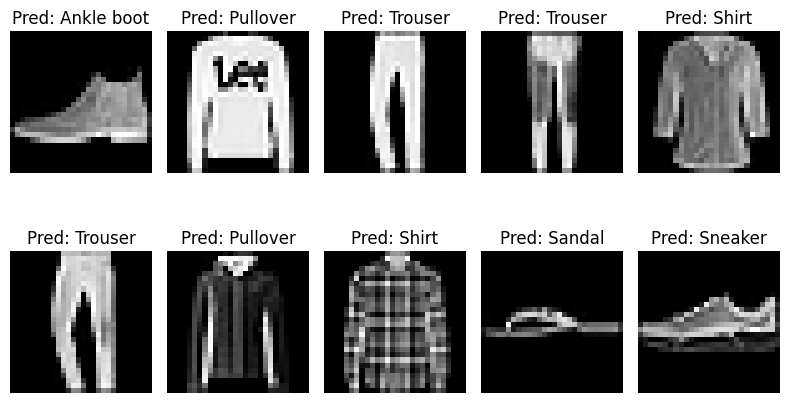

In [16]:
# 13. Example Prediction Visualization

plt.figure(figsize=(8,5))
for i in range(10):
    plt.subplot(2,5,i+1)
    plt.imshow(X_test[i], cmap='gray')
    plt.title(f"Pred: {class_names[y_pred_classes[i]]}")
    plt.axis('off')
plt.tight_layout()
plt.show()